# Phase 1E: collective accommodation around individual engagement

Metrica Sample Game 1 only. The diagnostic question is: **When the focal defender engages an opponent, can we observe coordinated teammate movement that appears to accommodate that engagement?**

**Collective accommodation** is provisional language for teammate movement that appears to absorb or support an individual defender's engagement. It is a hypothesis, not a conclusion or causal claim. This notebook does not define a score, compare team quality, classify success, infer assignments, optimize thresholds, fit a model, or expand the dataset.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
pd.DataFrame({'file':[HOME_PATH.name,AWAY_PATH.name],'sha256':[sha256(HOME_PATH),sha256(AWAY_PATH)]})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...


In [2]:
def load_tracking(path,team):
    header=pd.read_csv(path,header=None,nrows=3); ps=[str(int(float(v))) for v in header.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ps: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ps
home,home_players=load_tracking(HOME_PATH,'Home'); away,away_players=load_tracking(AWAY_PATH,'Away')
tracking={'Home':home,'Away':away}; players={'Home':home_players,'Away':away_players}; goalkeeper={'Home':'11','Away':'25'}
LENGTH=105.0; WIDTH=68.0
home.shape,away.shape

((145006, 33), (145006, 33))

## Fixed subset from existing Phase 1C quantities

No tackle search or new ranking is performed. Three of the 11 fixed tackle candidates are retained using quantities already reported in Phase 1C:

- **553.76 s, Away Player16 / Home Player9:** mean focal residual approach `+3.3095 m/s`.
- **1232.28 s, Away Player19 / Home Player10:** mean focal residual approach `+3.9710 m/s`.
- **3682.88 s, Home Player8 / Away Player15:** contrast case; centroid translation accounts for `1.3425 m/s` of `1.5491 m/s` focal approach, leaving `+0.2066 m/s` residual.

The first two are descriptively large positive residual examples; the third was chosen because collective translation accounts for much of apparent approach. These are not thresholds, categories, or good/bad labels. Each Phase 1C window remains −3 to +2 s around its anchor. Other-defender displacement diagnostics use window start to anchor so that post-contact movement is not silently folded into the engagement approach.

In [3]:
CASES=[
 {'anchor':553.76,'period':1,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'9','selection':'strong focal residual'},
 {'anchor':1232.28,'period':1,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selection':'strong focal residual'},
 {'anchor':3682.88,'period':2,'def_team':'Home','focal':'8','opp_team':'Away','opponent':'15','selection':'collective-translation contrast'}]
def case_window(c):
    d=tracking[c['def_team']]; o=tracking[c['opp_team']]
    w=d[(d.Period==c['period'])&d['Time [s]'].between(c['anchor']-3,c['anchor']+2)].copy()
    return w.merge(o[['Frame',f"{c['opp_team']}_{c['opponent']}_x",f"{c['opp_team']}_{c['opponent']}_y"]],on='Frame',validate='one_to_one')
def outfield_refs(c,w): return [p for p in players[c['def_team']] if p not in {c['focal'],goalkeeper[c['def_team']]} and w[f"{c['def_team']}_{p}_x"].notna().any()]
[(c['anchor'],case_window(c).shape) for c in CASES]

[(553.76, (126, 35)), (1232.28, (126, 35)), (3682.88, (126, 35))]

## Soccer-first trajectories

Circles mark window starts and `X` marks ends. Faint arrows show each other outfield defender's displacement from window start to the tackle anchor. The centroid is leave-one-out and outfield-only. Trajectories are displayed in documented physical pitch units without orientation flipping.

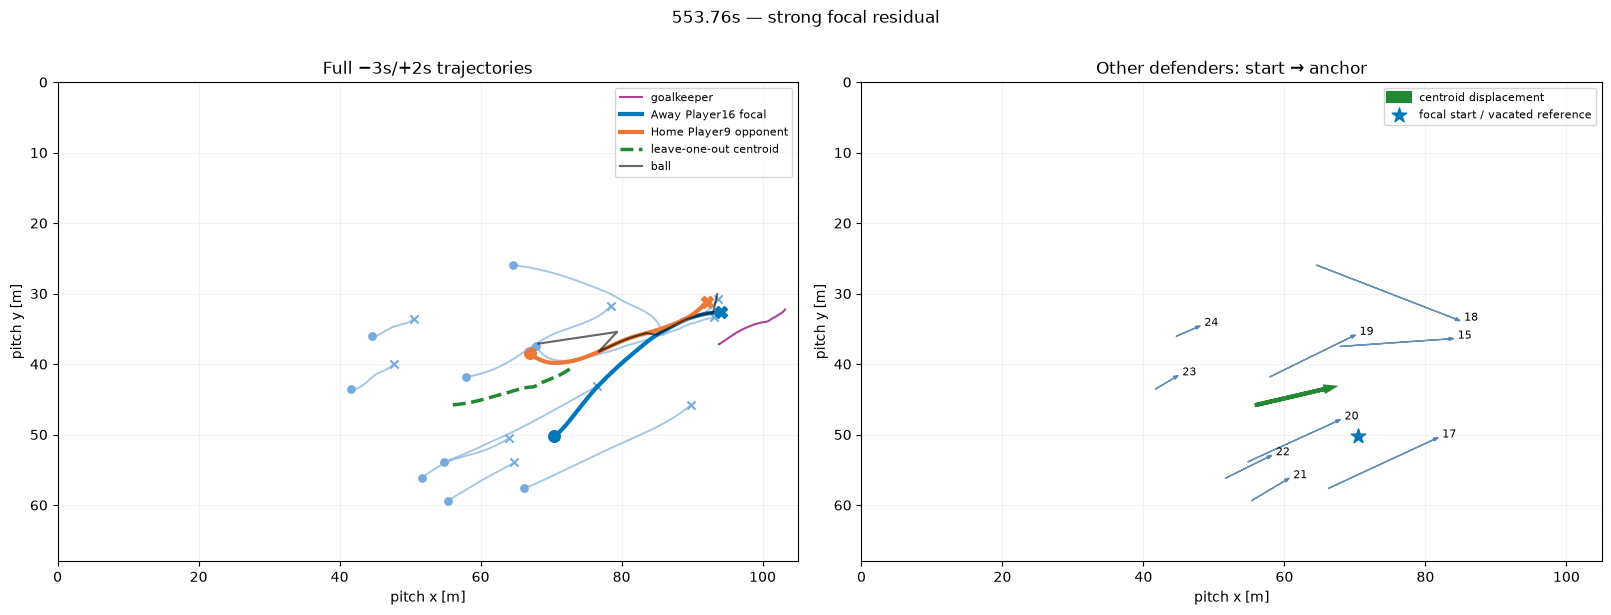

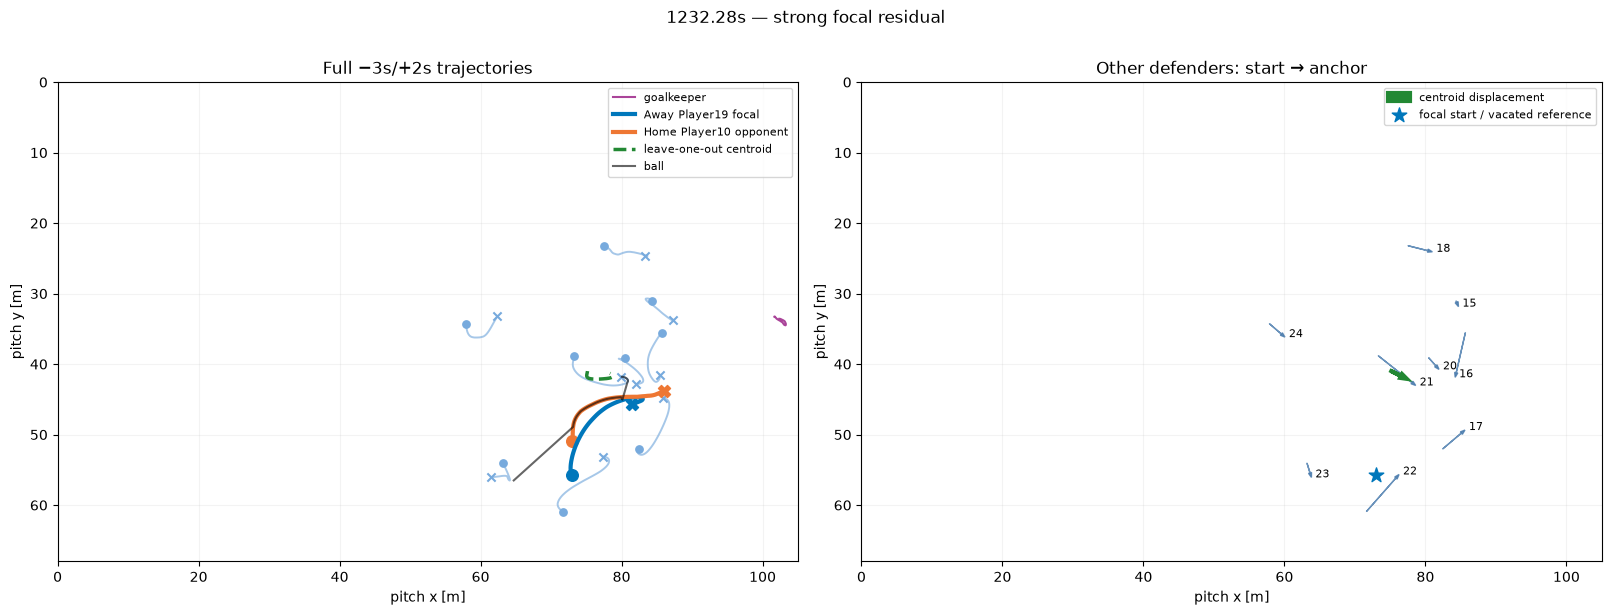

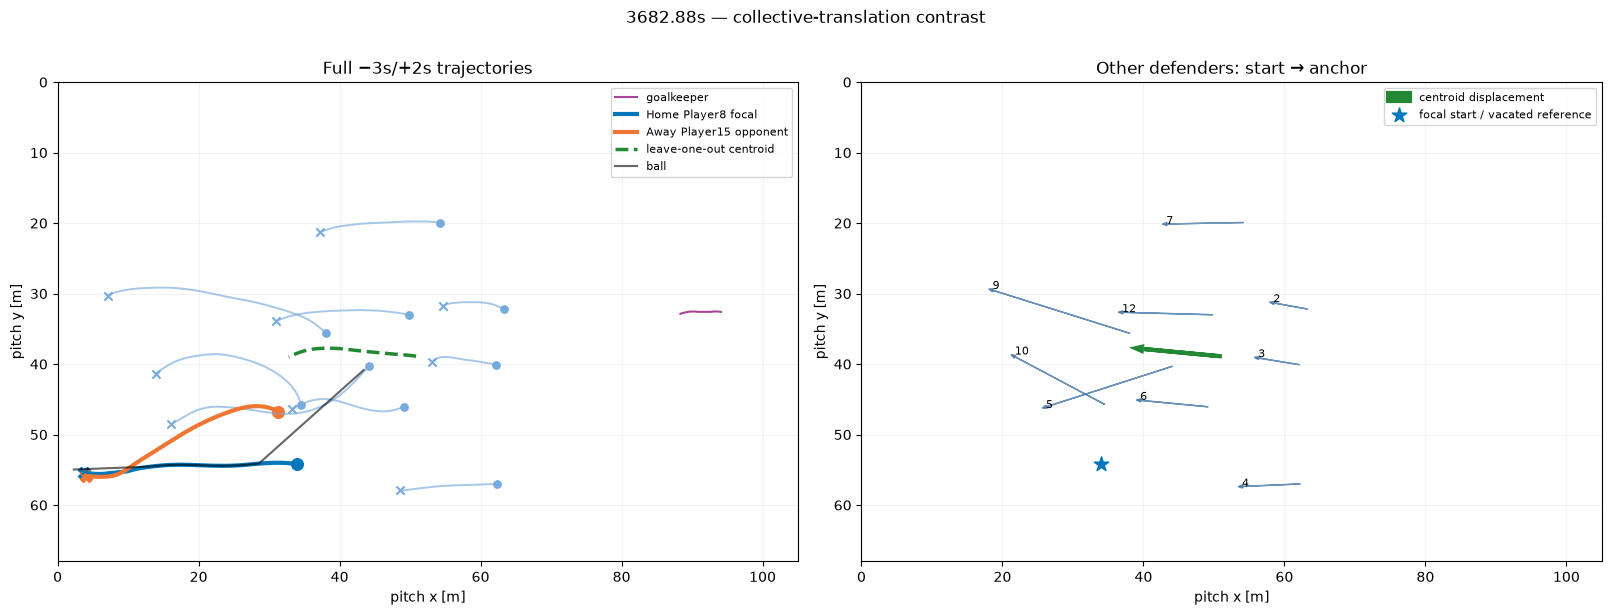

In [4]:
def trajectory_plot(c):
    w=case_window(c); refs=outfield_refs(c,w); team=c['def_team']; focal=c['focal']; oppteam=c['opp_team']; opp=c['opponent']; ai=(w['Time [s]']-c['anchor']).abs().idxmin()
    w['centroid_x']=w[[f'{team}_{p}_x' for p in refs]].mean(axis=1)*LENGTH; w['centroid_y']=w[[f'{team}_{p}_y' for p in refs]].mean(axis=1)*WIDTH
    fig,axes=plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
    ax=axes[0]
    for p in refs:
        x=w[f'{team}_{p}_x']*LENGTH; y=w[f'{team}_{p}_y']*WIDTH; ax.plot(x,y,color='#77aadd',alpha=.65,lw=1.4); ax.scatter(x.iloc[0],y.iloc[0],color='#77aadd',s=28); ax.scatter(x.iloc[-1],y.iloc[-1],color='#77aadd',marker='x',s=35)
    gx=w[f"{team}_{goalkeeper[team]}_x"]*LENGTH; gy=w[f"{team}_{goalkeeper[team]}_y"]*WIDTH; ax.plot(gx,gy,color='#aa4499',lw=1.5,label='goalkeeper')
    fx=w[f'{team}_{focal}_x']*LENGTH; fy=w[f'{team}_{focal}_y']*WIDTH; ox=w[f'{oppteam}_{opp}_x']*LENGTH; oy=w[f'{oppteam}_{opp}_y']*WIDTH
    ax.plot(fx,fy,color='#0077bb',lw=3,label=f'{team} Player{focal} focal'); ax.plot(ox,oy,color='#ee7733',lw=3,label=f'{oppteam} Player{opp} opponent'); ax.plot(w.centroid_x,w.centroid_y,color='#228833',lw=2.5,ls='--',label='leave-one-out centroid'); ax.plot(w[f'{team}_ball_x']*LENGTH,w[f'{team}_ball_y']*WIDTH,color='black',alpha=.6,label='ball')
    for x,y,color in [(fx,fy,'#0077bb'),(ox,oy,'#ee7733')]: ax.scatter(x.iloc[0],y.iloc[0],color=color,s=70); ax.scatter(x.iloc[-1],y.iloc[-1],color=color,marker='X',s=75)
    ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',xlabel='pitch x [m]',ylabel='pitch y [m]',title='Full −3s/+2s trajectories'); ax.grid(alpha=.15); ax.legend(fontsize=8)
    ax=axes[1]
    fs=np.array([w.loc[w.index[0],f'{team}_{focal}_x']*LENGTH,w.loc[w.index[0],f'{team}_{focal}_y']*WIDTH])
    for p in refs:
        sx=w.loc[w.index[0],f'{team}_{p}_x']*LENGTH; sy=w.loc[w.index[0],f'{team}_{p}_y']*WIDTH; ex=w.loc[ai,f'{team}_{p}_x']*LENGTH; ey=w.loc[ai,f'{team}_{p}_y']*WIDTH
        ax.arrow(sx,sy,ex-sx,ey-sy,color='#4477aa',alpha=.8,length_includes_head=True,head_width=.45); ax.text(ex,ey,f' {p}',fontsize=8)
    cs=np.array([w.centroid_x.iloc[0],w.centroid_y.iloc[0]]); ce=np.array([w.loc[ai,'centroid_x'],w.loc[ai,'centroid_y']]); ax.arrow(*cs,*(ce-cs),color='#228833',lw=3,length_includes_head=True,head_width=.6,label='centroid displacement')
    ax.scatter(*fs,color='#0077bb',marker='*',s=120,label='focal start / vacated reference'); ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',xlabel='pitch x [m]',ylabel='pitch y [m]',title='Other defenders: start → anchor'); ax.grid(alpha=.15); ax.legend(fontsize=8)
    fig.suptitle(f"{c['anchor']:.2f}s — {c['selection']}",y=1.02); plt.show()
for c in CASES: trajectory_plot(c)

## Other-defender descriptive diagnostics

For each non-focal outfield defender, `dx/dy` is start→anchor displacement. `focal spacing change` is anchor distance to the focal defender minus start distance, so negative means local spacing tightened. `toward focal-start space` is start distance to the focal defender's starting position minus anchor distance to that fixed location, so positive means movement toward the space the focal occupied at window start. This fixed-point diagnostic does not prove that space was tactically vacated or covered. Nearest-at-start rank is descriptive only.

In [5]:
def teammate_diagnostics(c):
    w=case_window(c); refs=outfield_refs(c,w); team=c['def_team']; f=c['focal']; ai=(w['Time [s]']-c['anchor']).abs().idxmin(); si=w.index[0]
    fs=np.array([w.loc[si,f'{team}_{f}_x']*LENGTH,w.loc[si,f'{team}_{f}_y']*WIDTH]); fa=np.array([w.loc[ai,f'{team}_{f}_x']*LENGTH,w.loc[ai,f'{team}_{f}_y']*WIDTH]); rows=[]
    for p in refs:
        start=np.array([w.loc[si,f'{team}_{p}_x']*LENGTH,w.loc[si,f'{team}_{p}_y']*WIDTH]); end=np.array([w.loc[ai,f'{team}_{p}_x']*LENGTH,w.loc[ai,f'{team}_{p}_y']*WIDTH])
        rows.append({'player':p,'dx_m':end[0]-start[0],'dy_m':end[1]-start[1],'start_focal_distance_m':np.linalg.norm(start-fs),'anchor_focal_distance_m':np.linalg.norm(end-fa),'focal_spacing_change_m':np.linalg.norm(end-fa)-np.linalg.norm(start-fs),'toward_focal_start_space_m':np.linalg.norm(start-fs)-np.linalg.norm(end-fs)})
    out=pd.DataFrame(rows).sort_values('start_focal_distance_m'); out['nearest_at_start_rank']=np.arange(1,len(out)+1)
    start_xy=np.array([[w.loc[si,f'{team}_{p}_x']*LENGTH,w.loc[si,f'{team}_{p}_y']*WIDTH] for p in refs]); end_xy=np.array([[w.loc[ai,f'{team}_{p}_x']*LENGTH,w.loc[ai,f'{team}_{p}_y']*WIDTH] for p in refs])
    summary={'anchor':c['anchor'],'centroid_dx_m':end_xy[:,0].mean()-start_xy[:,0].mean(),'centroid_dy_m':end_xy[:,1].mean()-start_xy[:,1].mean(),'x_spread_start_m':start_xy[:,0].std(),'x_spread_anchor_m':end_xy[:,0].std(),'y_spread_start_m':start_xy[:,1].std(),'y_spread_anchor_m':end_xy[:,1].std(),'ball_missing_frames':int(w[f'{team}_ball_x'].isna().sum())}
    return out,summary
summaries=[]
for c in CASES:
    table,summary=teammate_diagnostics(c); summaries.append(summary); print(f"Case {c['anchor']:.2f}s — all other outfield defenders"); display(table.round(3))
pd.DataFrame(summaries).round(3)

Case 553.76s — all other outfield defenders


,player,dx_m,dy_m,start_focal_distance_m,anchor_focal_distance_m,focal_spacing_change_m,toward_focal_start_space_m,nearest_at_start_rank
1,17,15.605,-7.230,8.508,14.896,6.388,-2.926,1
0,15,16.136,-1.117,12.972,1.094,-11.879,-6.457,2
3,19,12.188,-5.980,15.044,14.880,-0.165,0.659,3
4,20,13.180,-6.008,16.017,20.818,4.802,12.635,4
5,21,5.364,-3.193,17.630,31.679,14.049,6.243,5
6,22,6.607,-3.254,19.695,31.741,12.046,7.233,6
2,18,20.384,7.900,24.980,2.011,-22.969,3.082,7
8,24,3.439,-1.495,29.391,36.925,7.534,2.130,8
7,23,3.283,-1.965,29.477,40.429,10.952,2.622,9


Case 1232.28s — all other outfield defenders


,player,dx_m,dy_m,start_focal_distance_m,anchor_focal_distance_m,focal_spacing_change_m,toward_focal_start_space_m,nearest_at_start_rank
6,22,4.624,-5.254,5.324,11.221,5.897,2.005,1
7,23,0.632,2.031,9.890,19.612,9.722,0.774,2
2,17,3.160,-2.680,10.211,6.960,-3.251,-3.983,3
5,21,5.310,4.215,16.939,2.548,-14.390,3.009,4
4,20,1.482,1.664,18.276,4.732,-13.544,0.790,5
1,16,-1.451,6.341,23.891,5.246,-18.645,6.009,6
8,24,2.208,1.905,26.244,21.923,-4.321,2.817,7
0,15,0.340,0.813,27.220,14.036,-13.183,0.587,8
3,18,3.463,0.868,32.865,21.057,-11.808,0.183,9


Case 3682.88s — all other outfield defenders


,player,dx_m,dy_m,start_focal_distance_m,anchor_focal_distance_m,focal_spacing_change_m,toward_focal_start_space_m,nearest_at_start_rank
7,10,-13.342,-7.088,8.497,17.751,9.254,-11.670,1
3,5,-18.497,5.938,17.189,14.867,-2.321,5.614,2
4,6,-10.218,-0.974,17.228,27.378,10.150,6.839,3
6,9,-20.021,-6.287,19.023,25.638,6.615,-10.541,4
8,12,-13.430,-0.365,26.466,31.853,5.387,4.754,5
2,4,-8.843,0.387,28.385,40.246,11.861,8.723,6
1,3,-6.432,-1.052,31.477,45.177,13.700,4.998,7
0,2,-5.416,-0.979,36.633,50.326,13.693,3.493,8
5,7,-11.532,0.219,39.803,45.252,5.449,4.639,9


,anchor,centroid_dx_m,centroid_dy_m,x_spread_start_m,x_spread_anchor_m,y_spread_start_m,y_spread_anchor_m,ball_missing_frames
0,553.76,10.687,-2.483,8.676,14.147,10.937,8.181,0
1,1232.28,2.196,1.100,9.065,8.740,11.489,9.998,0
2,3682.88,-11.970,-1.133,10.015,14.138,9.886,10.348,0


In [6]:
for c in CASES:
    table,_=teammate_diagnostics(c); print(f"Case {c['anchor']:.2f}s — three nearest teammates at window start"); display(table.head(3)[['player','dx_m','dy_m','focal_spacing_change_m','toward_focal_start_space_m']].round(3))

Case 553.76s — three nearest teammates at window start


,player,dx_m,dy_m,focal_spacing_change_m,toward_focal_start_space_m
1,17,15.605,-7.230,6.388,-2.926
0,15,16.136,-1.117,-11.879,-6.457
3,19,12.188,-5.980,-0.165,0.659


Case 1232.28s — three nearest teammates at window start


,player,dx_m,dy_m,focal_spacing_change_m,toward_focal_start_space_m
6,22,4.624,-5.254,5.897,2.005
7,23,0.632,2.031,9.722,0.774
2,17,3.160,-2.680,-3.251,-3.983


Case 3682.88s — three nearest teammates at window start


,player,dx_m,dy_m,focal_spacing_change_m,toward_focal_start_space_m
7,10,-13.342,-7.088,9.254,-11.670
3,5,-18.497,5.938,-2.321,5.614
4,6,-10.218,-0.974,10.150,6.839


## Case interpretations and stopping point

Interpretation distinguishes four objects: **focal engagement** is the focal defender's opponent-directed movement already documented in Phase 1C; **whole-block translation** is summarized by the leave-one-out centroid displacement; **local teammate compensation** concerns nearby individual displacement and spacing changes; **resulting structural change** concerns the observed x/y spread and geometry after those movements. None is assumed to cause another.

**553.76 s — mixed evidence.** The focal engagement occurs within substantial whole-block translation: the other-outfield centroid moves `+10.687 m` in x and `−2.483 m` in y. Players15 and18 markedly reduce their distance to the moving focal defender, which is consistent with local support around the engagement. Against a simple accommodation reading, the nearest-at-start Player17 moves farther from the focal defender, several others also separate, and x spread expands from `8.676` to `14.147 m` even as y spread contracts. General forward translation, compression in one axis, rotation, and ball response remain plausible. Resulting structure is deformed rather than simply preserved.

**1232.28 s — strongest accommodation-consistent case in this fixed subset, but still ambiguous.** Whole-block translation is modest (`+2.196 m` x, `+1.100 m` y) relative to the focal movement. Seven of nine other outfield defenders reduce their spacing to the moving focal defender, while x spread decreases from `9.065` to `8.740 m` and y spread from `11.489` to `9.998 m`. Players21,20, and16 show especially large spacing reductions. This is consistent with coordinated compression/support around engagement. However, the two nearest-at-start teammates move farther away, and the same pattern could reflect ball-oriented compression, rotation, or independent responsibilities rather than accommodation caused by Player19.

**3682.88 s — limited accommodation evidence and strong collective-translation explanation.** The centroid moves `−11.970 m` in x and `−1.133 m` in y, visually matching the general block movement already identified in Phase 1C. Most teammates, including nearest-at-start Players10 and6, increase their distance from the focal defender; x spread expands from `10.015` to `14.138 m`, while y spread changes little. Player5 moves toward the focal defender's starting space and slightly tightens its focal spacing, which is locally consistent with compensation, but one movement is insufficient to establish a coherent collective pattern. Translation, rotation, transition, and ball response are stronger visible alternatives.

Across the three cases, focal engagement, whole-block translation, local teammate compensation, and resulting structural change do not collapse into one phenomenon. The fixed examples provide one accommodation-consistent pattern, one mixed pattern, and one weak pattern, but these are soccer interpretations rather than classifications. A centroid can represent translation but not line-specific rotation or deformation.

This notebook stops after these three fixed-case descriptive diagnostics. It creates no accommodation score, causal claim, team-quality comparison, success classification, assignment inference, optimized threshold, HMM, machine-learning model, or expanded dataset.